In [2]:
import pandas as pd

df = pd.read_csv("../data/diabetes.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())

Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose      

In [3]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    print(col, (df[col] == 0).sum())

Glucose 0
BloodPressure 0
SkinThickness 0
Insulin 0
BMI 0


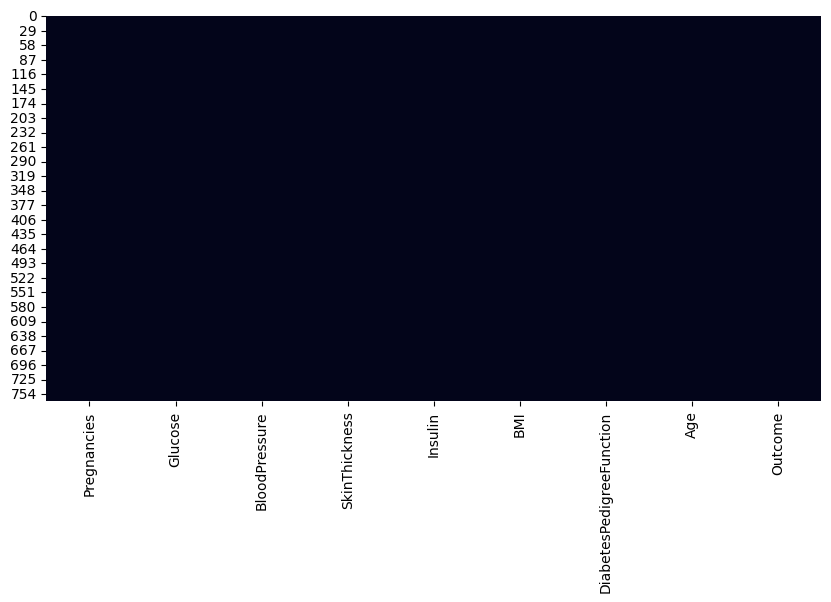

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [5]:
cols = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

df[cols] = df[cols].replace(0, np.nan)

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

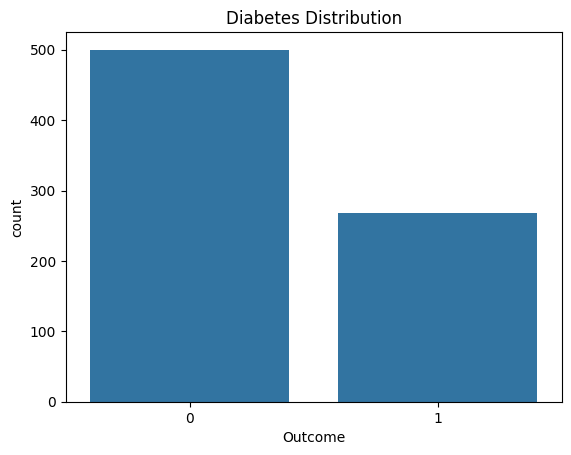

Outcome
0    500
1    268
Name: count, dtype: int64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Distribution")
plt.show()

print(df["Outcome"].value_counts())

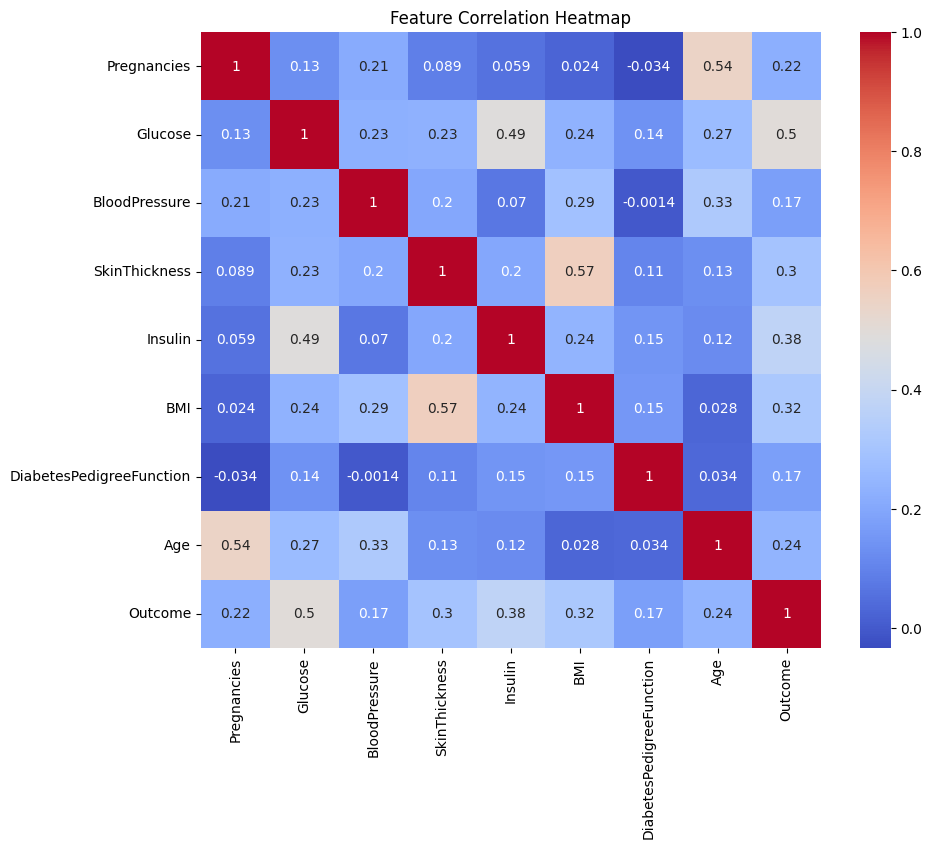

In [8]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

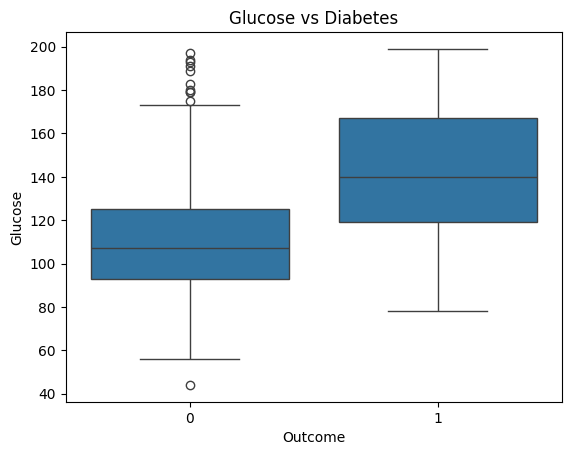

In [9]:
sns.boxplot(
    x="Outcome",
    y="Glucose",
    data=df
)

plt.title("Glucose vs Diabetes")
plt.show()

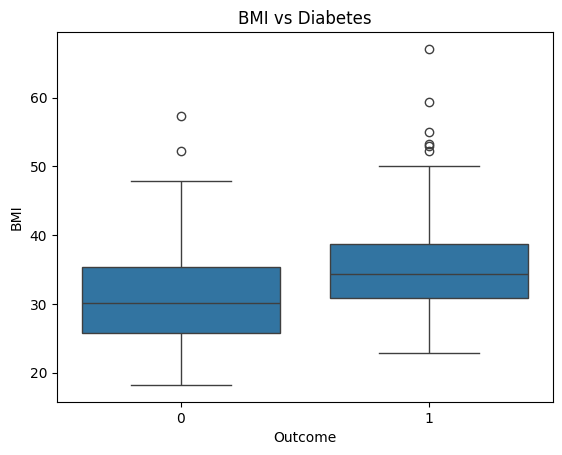

In [10]:
sns.boxplot(
    x="Outcome",
    y="BMI",
    data=df
)

plt.title("BMI vs Diabetes")
plt.show()

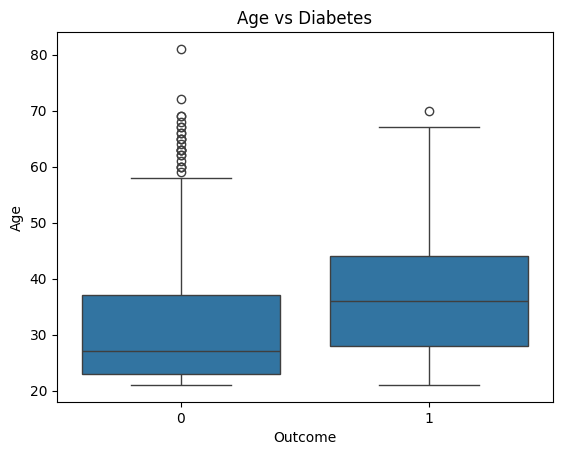

In [11]:
sns.boxplot(
    x="Outcome",
    y="Age",
    data=df
)

plt.title("Age vs Diabetes")
plt.show()

In [12]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [13]:
correlation = df.corr()

print(
    correlation["Outcome"]
    .sort_values(ascending=False)
)

Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

preds = model.predict(X_test)

accuracy = accuracy_score(y_test, preds)

print("Accuracy:", accuracy)

Accuracy: 0.7727272727272727


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    print(f"{name}: {acc:.4f}")

Decision Tree: 0.8377
Random Forest: 0.8831


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree:", dt_acc)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest:", rf_acc)

Decision Tree: 0.8376623376623377
Random Forest: 0.8831168831168831


In [17]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_preds)

print("XGBoost:", xgb_acc)

XGBoost: 0.8571428571428571


In [18]:
results = {
    "Logistic Regression": 0.7727,
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "XGBoost": xgb_acc
}

print(results)

{'Logistic Regression': 0.7727, 'Decision Tree': 0.8376623376623377, 'Random Forest': 0.8831168831168831, 'XGBoost': 0.8571428571428571}


In [19]:
import joblib

joblib.dump(
    rf_model,
    "../models/diabetes_model.pkl"
)

['../models/diabetes_model.pkl']

In [20]:
import os

print(os.path.exists("../models/diabetes_model.pkl"))

True
